
**Problem Statement**

Netflix contains thousands of movies and TV shows from different countries, genres, and years. Analyzing such a large dataset manually is difficult. This project uses data visualization techniques to explore Netflix content and identify trends, distributions, and patterns that can help understand the platform's content library.

**Objective**

To perform Exploratory Data Analysis (EDA) on the Netflix dataset.
To visualize content distribution using charts and graphs.
To identify trends based on content type, release year, country, rating, and genre.

In [ ]:
from google.colab import files
files.upload()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Netflix_Dataset.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

In [ ]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['country'].fillna('Unknown', inplace=True)

In [ ]:
df['director'].fillna('Not Available', inplace=True)

In [ ]:
df['cast'].fillna('Not Available', inplace=True)

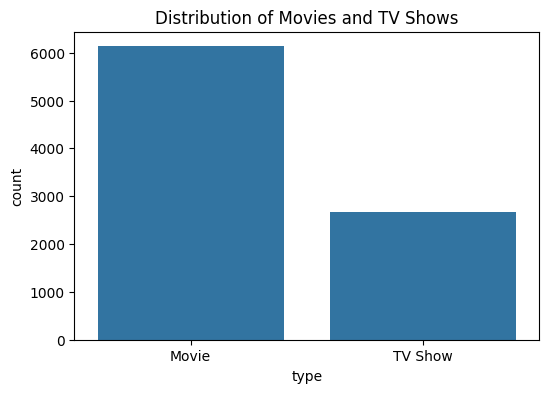

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title('Distribution of Movies and TV Shows')
plt.show()

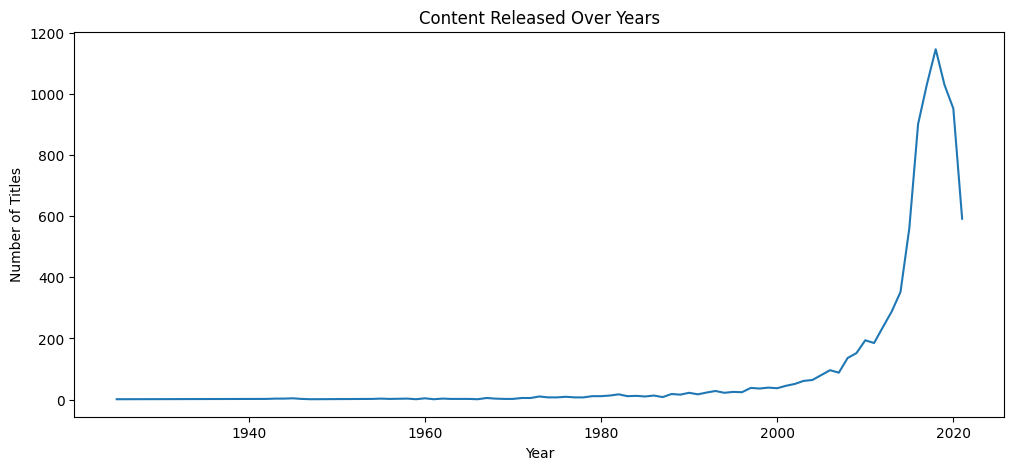

In [ ]:
plt.figure(figsize=(12,5))

df['release_year'].value_counts().sort_index().plot()

plt.title('Content Released Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

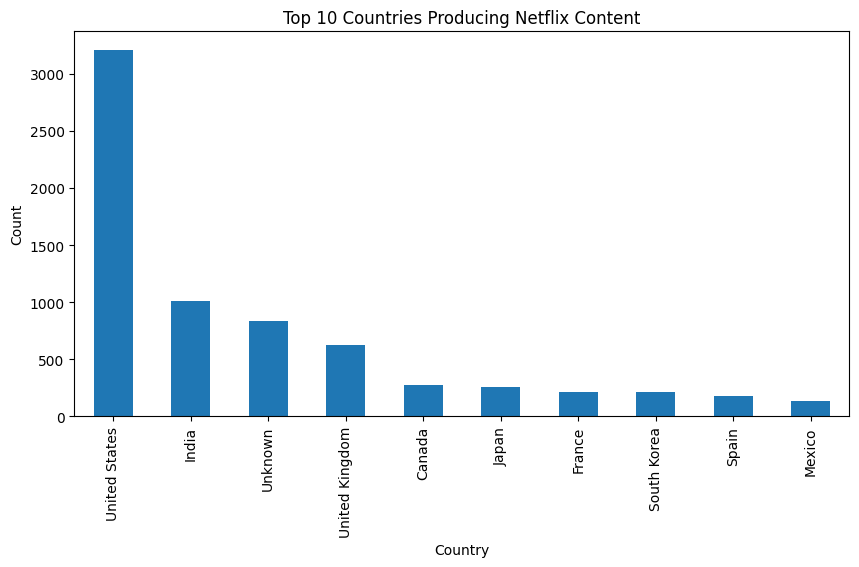

In [ ]:
top_countries = (
    df['country']
    .dropna()
    .str.split(',')
    .str[0]
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')

plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

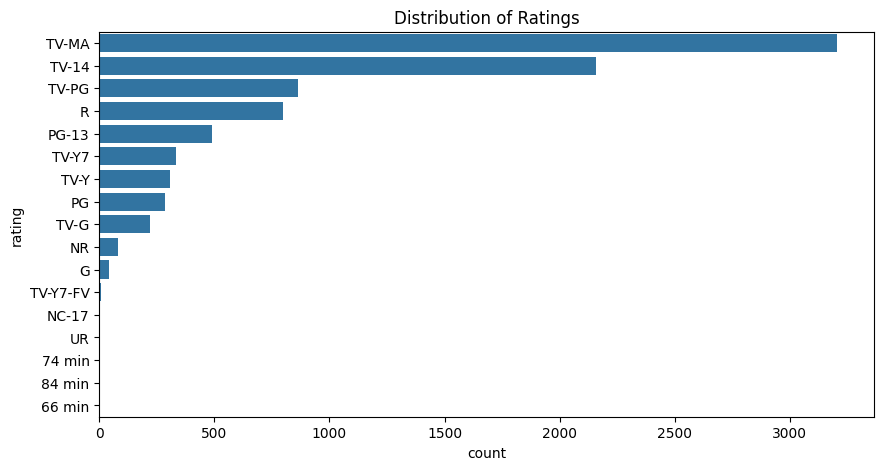

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title('Distribution of Ratings')
plt.show()

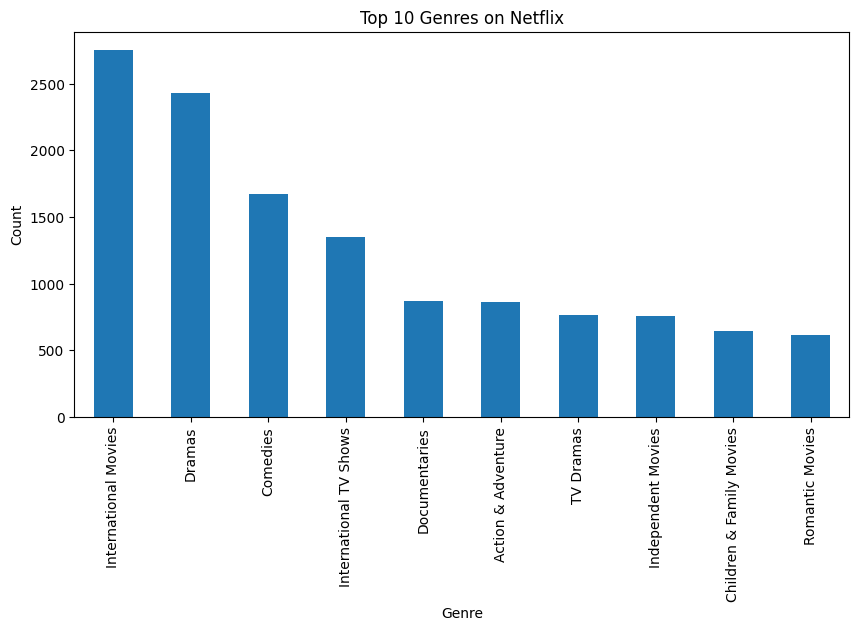

In [ ]:
genres = (
    df['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
)

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind='bar')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

In [ ]:
correlation = df.corr(numeric_only=True)
correlation

,release_year
release_year,1.0


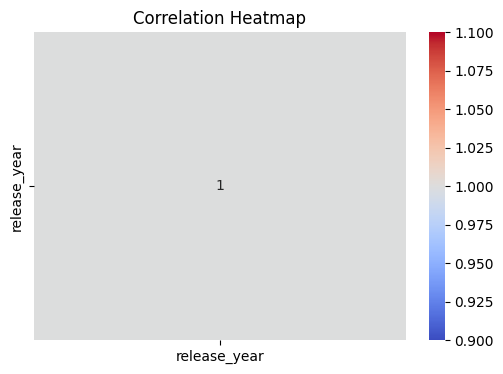

In [ ]:
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Key Insights**

From this analysis, I observed several important insights.

Movies are more common than TV Shows on Netflix.

The number of released titles has increased significantly over time.

A few countries contribute a large portion of Netflix content.

Ratings such as TV-MA and TV-14 are among the most frequently occurring categories.

Certain genres dominate the platform's library.

The correlation analysis showed limited relationships between the available numerical variables.